<a href="https://www.kaggle.com/code/ergunenesyazirlioglu/churn-prediction?scriptVersionId=280534421" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# Veri Görselleştirme

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Churn', ylabel='count'>

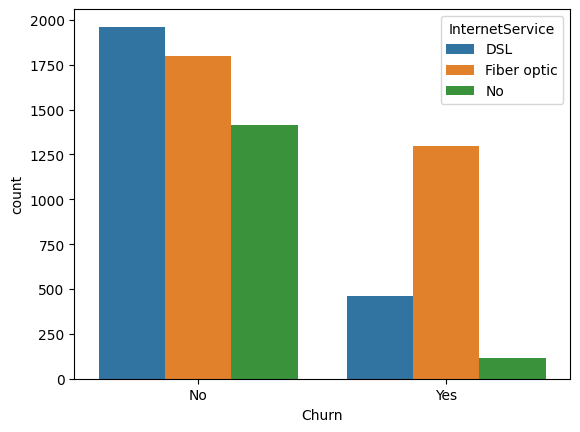

In [7]:
sns.countplot(df, x="Churn", hue="InternetService")

<Axes: xlabel='Churn', ylabel='count'>

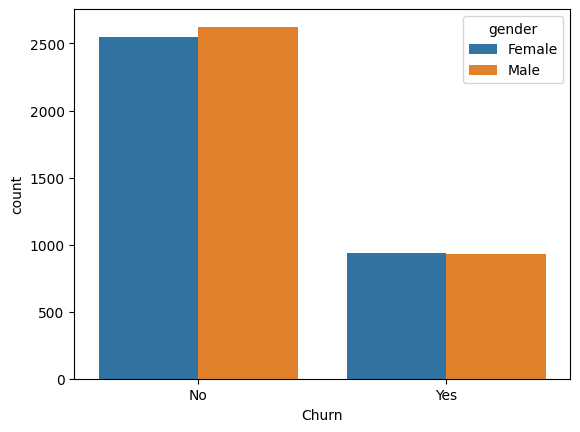

In [8]:
sns.countplot(df, x="Churn", hue="gender")

<Axes: xlabel='PhoneService', ylabel='count'>

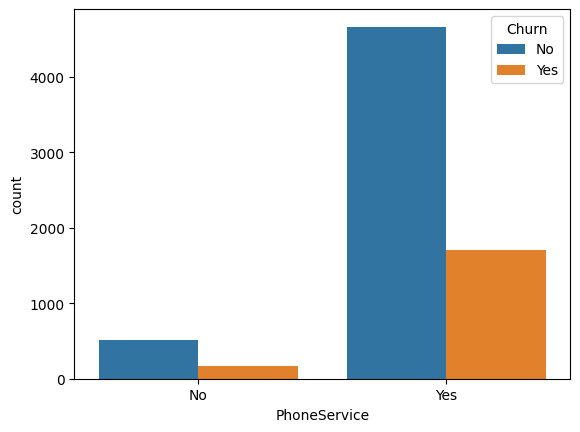

In [9]:
sns.countplot(df, x="PhoneService", hue="Churn")

<Axes: xlabel='PaperlessBilling', ylabel='count'>

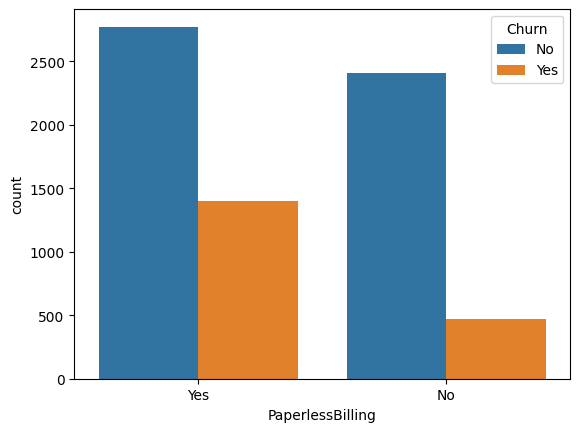

In [10]:
sns.countplot(df, x="PaperlessBilling", hue="Churn")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

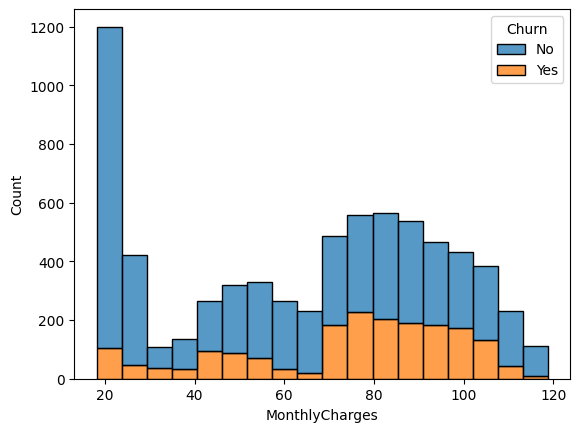

In [11]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", multiple="stack")

<Axes: xlabel='MonthlyCharges', ylabel='Churn'>

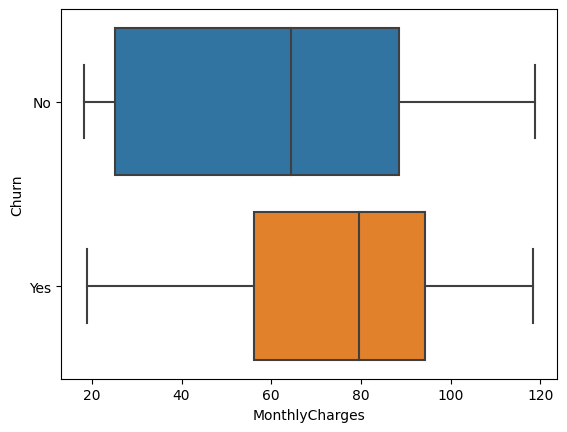

In [12]:
sns.boxplot(data=df, x="MonthlyCharges", y="Churn")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='tenure', ylabel='Count'>

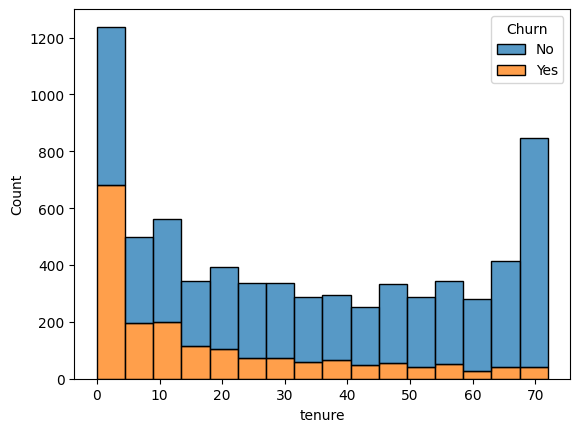

In [13]:
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack")

<Axes: xlabel='tenure', ylabel='Churn'>

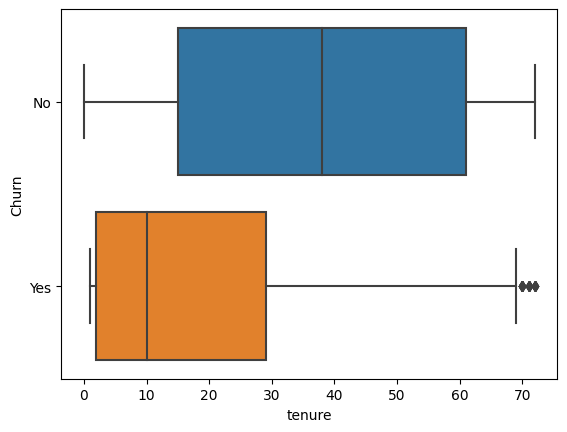

In [14]:
sns.boxplot(data=df, x="tenure", y="Churn")

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='Contract', ylabel='Count'>

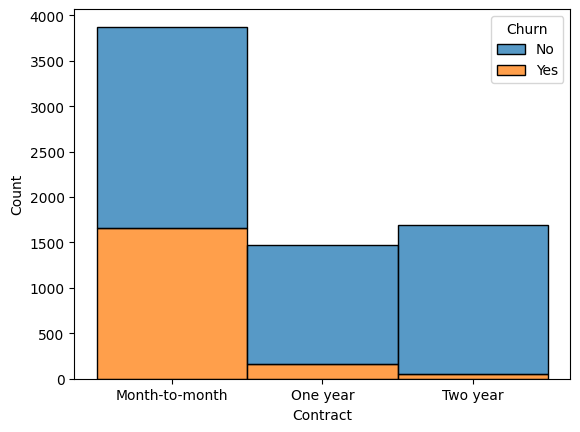

In [15]:
sns.histplot(data=df, x="Contract", hue="Churn", multiple="stack")

# Ön İşleme

In [16]:
df = df[(df["TotalCharges"] != " ")]

In [17]:
df.nunique()

customerID          7032
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [18]:
df.drop(df.columns.drop(['gender', 'tenure', 'MultipleLines','Churn','PaperlessBilling','MonthlyCharges','TotalCharges','PaymentMethod','Contract','SeniorCitizen',  'InternetService']), axis=1, inplace=True)
#

In [19]:
df

,gender,SeniorCitizen,tenure,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,No phone service,DSL,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,34,No,DSL,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,2,No,DSL,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,45,No phone service,DSL,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,2,No,Fiber optic,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,24,Yes,DSL,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,72,Yes,Fiber optic,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,11,No phone service,DSL,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,4,Yes,Fiber optic,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [20]:
one_hot_encoded_df = pd.get_dummies(df, columns=['InternetService','Contract','MultipleLines','gender','PaymentMethod'], drop_first=True)

In [21]:
one_hot_encoded_df['Churn'] = one_hot_encoded_df['Churn'].map({'No': 0, 'Yes': 1})
one_hot_encoded_df['PaperlessBilling'] = one_hot_encoded_df['PaperlessBilling'].map({'No': 0, 'Yes': 1})

In [22]:
one_hot_encoded_df['TotalCharges'] = one_hot_encoded_df['TotalCharges'].astype(float)

In [23]:
one_hot_encoded_df[(one_hot_encoded_df["TotalCharges"] == " ")]


,SeniorCitizen,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,MultipleLines_No phone service,MultipleLines_Yes,gender_Male,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check


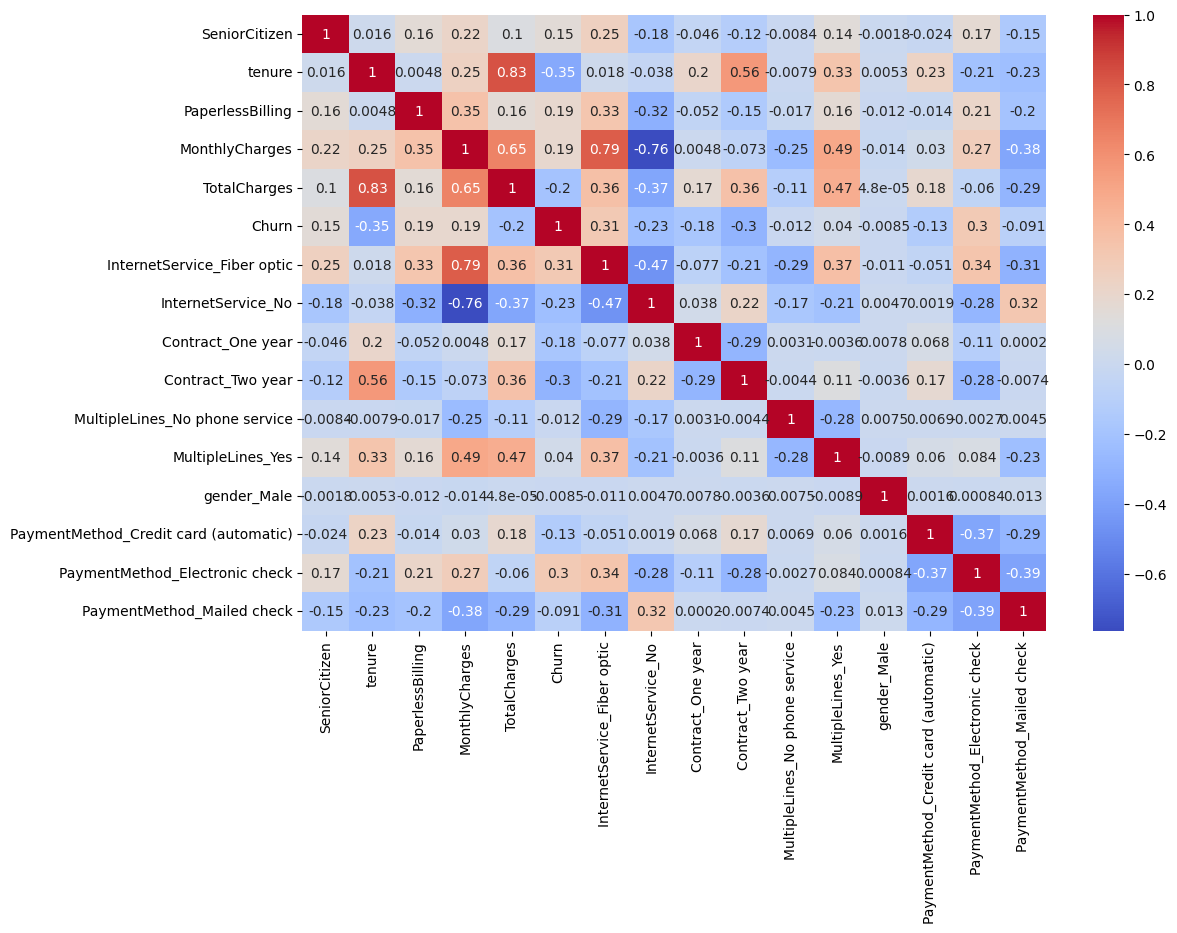

In [24]:
corr_matrix = one_hot_encoded_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

# Modeli Kurma

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X = one_hot_encoded_df.drop('Churn', axis=1)
y = one_hot_encoded_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

scaler.fit(X_train[numerical_cols])

X_train.loc[:, numerical_cols] = scaler.transform(X_train[numerical_cols])
X_test.loc[:, numerical_cols] = scaler.transform(X_test[numerical_cols])

/tmp/ipykernel_13/2133874102.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.3218163  -0.26741023  1.4440645  ...  0.14008375 -0.9194006
 -1.28614519]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, numerical_cols] = scaler.transform(X_train[numerical_cols])
/tmp/ipykernel_13/2133874102.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.07731992 -1.0416488   0.87357292 ... -1.20464639  0.18083315
  0.71057533]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test.loc[:, numerical_cols] = scaler.transform(X_test[numerical_cols])


In [29]:
X_train

,SeniorCitizen,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,MultipleLines_No phone service,MultipleLines_Yes,gender_Male,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,0,1.321816,0,0.981556,1.659900,True,False,False,True,False,True,True,True,False,False
7003,0,-0.267410,0,-0.971546,-0.562252,False,False,False,False,True,False,True,False,True,False
3355,0,1.444064,0,0.837066,1.756104,True,False,False,True,False,True,False,True,False,False
4494,0,-1.204646,0,0.641092,-0.908326,True,False,False,False,False,False,True,False,True,False
3541,0,0.669826,0,-0.808787,-0.101561,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,1,1.321816,1,0.197658,0.990321,True,False,True,False,False,False,True,False,False,False
5123,1,-0.715654,1,0.342148,-0.507338,True,False,False,False,False,False,False,True,False,False
4135,0,0.140084,1,0.926749,0.473507,False,False,False,True,False,True,False,True,False,False
4249,0,-0.919401,1,0.029917,-0.721544,False,False,True,False,False,False,False,False,False,True


In [30]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [31]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=1.33,      # Dengesiz veri setini düzelten sihirli parametre
    n_estimators=1000,           # Ağaç sayısı (artırılabilir, early_stopping durduracak)
    learning_rate=0.05,          # Daha yavaş ama güvenli öğrenme
    max_depth=5,                 # Aşırı öğrenmeyi (overfitting) engellemek için makul bir derinlik
    subsample=0.8,               # Her ağaçta verinin %80'ini kullan
    colsample_bytree=0.8,        # Her ağaçta özelliklerin %80'ini kullan
    random_state=42,
    eval_metric='auc',           # Dengesiz veride 'error' yerine 'auc' izlemek daha iyidir
    early_stopping_rounds=50     # 50 iterasyon boyunca iyileşme olmazsa dur
)

xgb_model.fit(
    X_train, 
    y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [32]:
y_pred = xgb_model.predict(X_test)

print("Optimize Edilmiş Sonuçlar:")
print(classification_report(y_test, y_pred))

print("\nKarmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))

Optimize Edilmiş Sonuçlar:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1033
           1       0.63      0.61      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.75      1407
weighted avg       0.80      0.80      0.80      1407


Karmaşıklık Matrisi:
[[900 133]
 [144 230]]
